<a href="https://colab.research.google.com/github/fatmakaraca/drift/blob/main/airlinesdataset20aug.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
from google.colab import drive
drive.mount('/content/drive')

PROJECT_PATH = "/content/drive/MyDrive/Covariate_Shift_Project"

DATA_PATH = PROJECT_PATH + "/datasets"

MODEL_PATH = PROJECT_PATH + "/models"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.io import arff

In [4]:
air, meta = arff.loadarff(DATA_PATH + "/airlines.arff")

df_air = pd.DataFrame(air)

for col in df_air.columns:
    if df_air[col].dtype == object:
        try:
            df_air[col] = df_air[col].str.decode("utf-8")
        except:
            pass

df_air.head()

,Airline,Flight,AirportFrom,AirportTo,DayOfWeek,Time,Length,Delay
0,CO,269.0,SFO,IAH,3,15.0,205.0,1
1,US,1558.0,PHX,CLT,3,15.0,222.0,1
2,AA,2400.0,LAX,DFW,3,20.0,165.0,1
3,AA,2466.0,SFO,DFW,3,20.0,195.0,1
4,AS,108.0,ANC,SEA,3,30.0,202.0,0


In [5]:
df_air.shape

(539383, 8)

In [6]:
df_air.describe(include="all")

,Airline,Flight,AirportFrom,AirportTo,DayOfWeek,Time,Length,Delay
count,539383,539383.000000,539383,539383,539383,539383.000000,539383.000000,539383
unique,18,NaN,293,293,7,NaN,NaN,2
top,WN,NaN,ATL,ATL,4,NaN,NaN,0
freq,94097,NaN,34449,34440,91445,NaN,NaN,299119
mean,NaN,2427.928630,NaN,NaN,NaN,802.728963,132.202007,NaN
std,NaN,2067.429837,NaN,NaN,NaN,278.045911,70.117016,NaN
min,NaN,1.000000,NaN,NaN,NaN,10.000000,0.000000,NaN
25%,NaN,712.000000,NaN,NaN,NaN,565.000000,81.000000,NaN
50%,NaN,1809.000000,NaN,NaN,NaN,795.000000,115.000000,NaN
75%,NaN,3745.000000,NaN,NaN,NaN,1035.000000,162.000000,NaN


In [7]:
df_air.isnull().sum().sum()

np.int64(0)

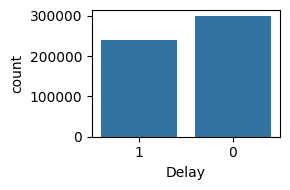

In [8]:
plt.figure(figsize=(3, 2))
sns.countplot(data=df_air,
              x="Delay")

plt.tight_layout()
plt.show()

In [9]:
numerical_air = df_air.select_dtypes(include=np.number).columns
categorical_air = df_air.select_dtypes(exclude=np.number).columns

print(numerical_air)
print(categorical_air)

Index(['Flight', 'Time', 'Length'], dtype='object')
Index(['Airline', 'AirportFrom', 'AirportTo', 'DayOfWeek', 'Delay'], dtype='object')


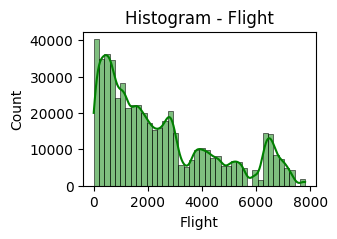

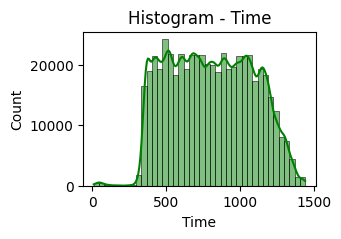

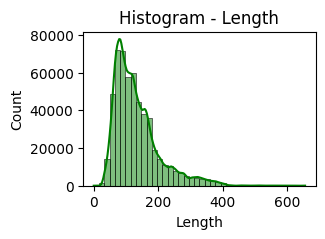

In [10]:
for col in numerical_air:

    plt.figure(figsize=(3,2))

    sns.histplot(df_air[col],
                 bins=40,
                 kde=True,
                 color = "green")

    plt.title(f"Histogram - {col}")

    plt.show()
    print("\n\n")

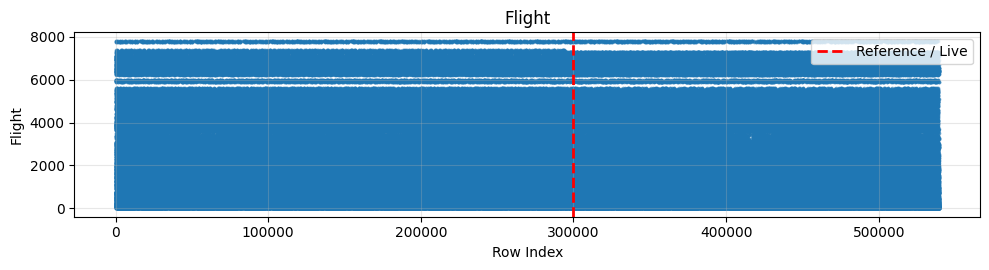

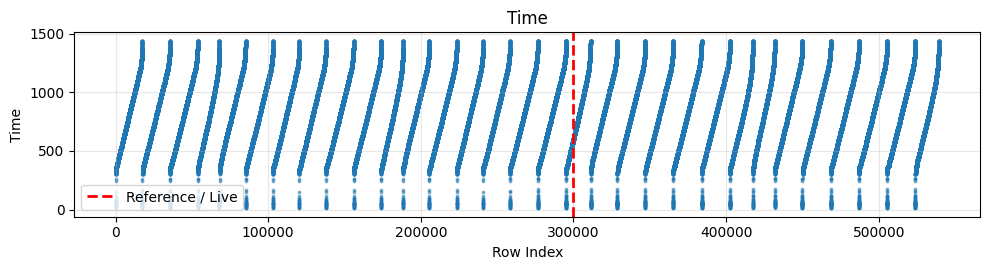

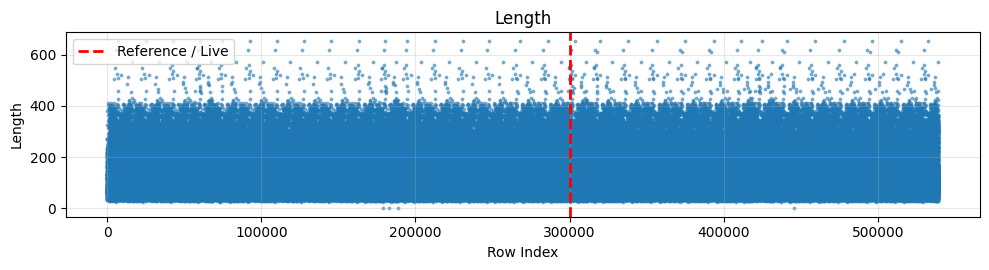

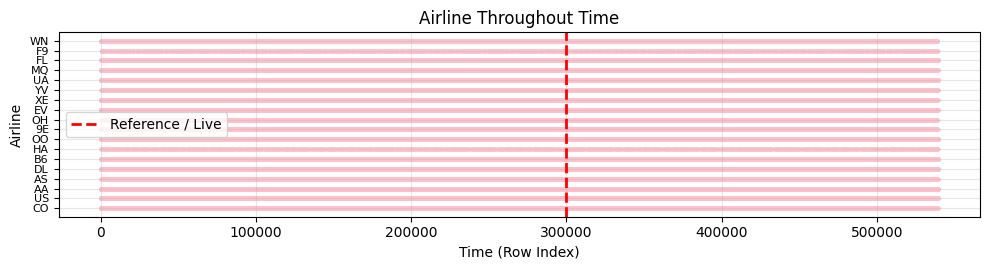

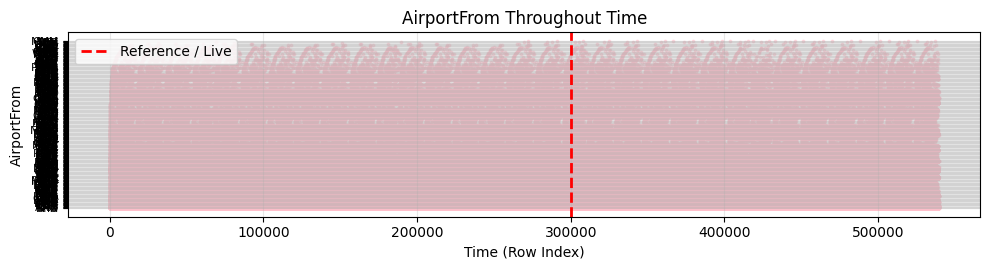

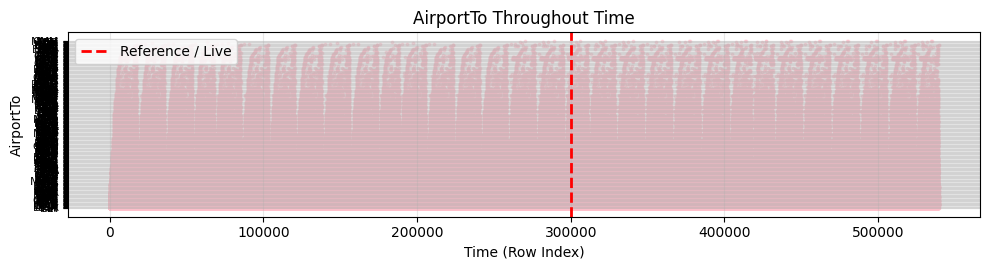

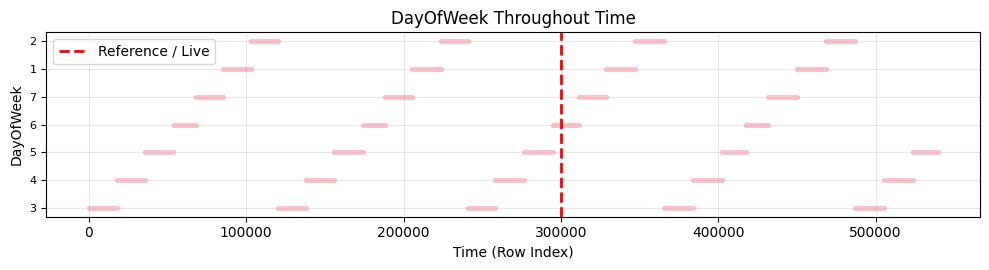

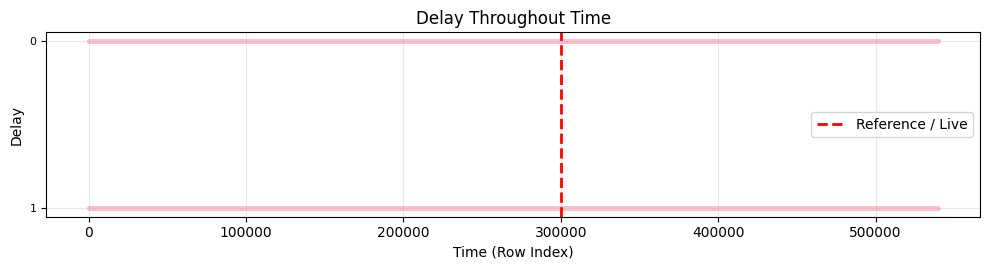

In [32]:

import pandas as pd
import matplotlib.pyplot as plt

drift_point = 300000

numeric_cols = df_air.select_dtypes(include=["int64", "float64"]).columns
categorical_cols = df_air.select_dtypes(include=["object"]).columns

for feature in numeric_cols:

    plt.figure(figsize=(10, 2.8))

    plt.scatter(
        df_air.index,
        df_air[feature],
        s=3,
        alpha=0.5
    )

    plt.axvline(
        drift_point,
        color="red",
        linestyle="--",
        linewidth=2,
        label="Reference / Live"
    )

    plt.title(f"{feature}")
    plt.xlabel("Row Index")
    plt.ylabel(feature)

    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


for feature in categorical_cols:

    codes, uniques = pd.factorize(df_air[feature])

    plt.figure(figsize=(10, 2.8))

    plt.scatter(
        df_air.index,
        codes,
        s=3,
        alpha=0.5,
        color= "pink"
    )

    plt.axvline(
        drift_point,
        color="red",
        linestyle="--",
        linewidth=2,
        label="Reference / Live"
    )

    plt.yticks(
        range(len(uniques)),
        uniques,
        fontsize=8
    )

    plt.title(f"{feature} Throughout Time")
    plt.xlabel("Time (Row Index)")
    plt.ylabel(feature)

    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

# İstatistiksel Testler

In [13]:
%cd /content/drive/MyDrive/Covariate_Shift_Project/notebooks

/content/drive/MyDrive/Covariate_Shift_Project/notebooks


In [14]:
from methods.two_sample_statistical_tests import (
    # KS
    ks_test,
    plot_ks,
    sliding_window_ks,

    # PSI
    calculate_psi,
    psi_test,
    plot_psi,
    sliding_window_psi,

    # Wasserstein
    calculate_wasserstein,
    wasserstein_test,
    plot_wasserstein,
    sliding_window_wasserstein,

    # Chi-Squared
    chi_squared_test,
    plot_chi_squared,
    sliding_window_chi_squared,

    # JSD
    calculate_jsd,
    jsd_test,
    plot_jsd,
    sliding_window_jsd,
)

## KS

In [30]:
df = df_air.copy()
if "Delay" in df.columns:
    df["Delay"] = df["Delay"].astype(int)
else:
    print("UYARI: 'Delay' kolonu bulunamadı, mevcut kolonlar:", df.columns)

print("Veri Tipleri:")
print(df.dtypes)


numerical_features = [
    "Time",
    "Length",
    "Flight"
]

import warnings
import numpy as np
import pandas as pd
from scipy.stats import ks_2samp

warnings.filterwarnings("ignore")

df_ref_window = df.iloc[:300000].copy()

df_live_stream = df.iloc[300000:].copy().reset_index(drop=True)

print(f"Sabit Referans Pencere Boyutu : {len(df_ref_window)} satır")
print(f"Taranacak Canlı Veri Boyutu   : {len(df_live_stream)} satır")


ks_monitoring_table, bonferroni_threshold = sliding_window_ks(
    df_ref=df_ref_window,
    df_stream=df_live_stream,
    features= numerical_features,
    window_size=1000,
    step_size=100,
    alpha=0.05
)




print("\n" + "=" * 60)
print("KAYAN PENCERE KS İZLEME TABLOSU")
print("=" * 60)

print(
    f"Bonferroni Eşiği (alpha/m): "
    f"{bonferroni_threshold:.6e}"
)

print(
    f"Toplam Oluşturulan Kayıt : "
    f"{len(ks_monitoring_table)}"
)




drift_alarms = (
    ks_monitoring_table[
        ks_monitoring_table["Drift"] == "ALARM"
    ]
    .sort_values(
        ["Step", "KS"],
        ascending=[True, False]
    )
)


print("\nAlarm Durumu Dağılımı")

print(
    ks_monitoring_table["Drift"]
    .value_counts()
)




print("\nFeature Bazında Alarm Sayısı")

print(
    ks_monitoring_table
    .groupby("Feature")["Drift"]
    .apply(
        lambda x: (x == "ALARM").sum()
    )
    .sort_values(ascending=False)
)


print("\nFeature Bazında NORMAL Sayısı")

print(
    ks_monitoring_table
    .groupby("Feature")["Drift"]
    .apply(
        lambda x: (x == "NORMAL").sum()
    )
    .sort_values(ascending=False)
)

Veri Tipleri:
Airline         object
Flight         float64
AirportFrom     object
AirportTo       object
DayOfWeek       object
Time           float64
Length         float64
Delay            int64
dtype: object
Sabit Referans Pencere Boyutu : 300000 satır
Taranacak Canlı Veri Boyutu   : 239383 satır

KAYAN PENCERE KS İZLEME TABLOSU
Bonferroni Eşiği (alpha/m): 1.666667e-02
Toplam Oluşturulan Kayıt : 7152

Alarm Durumu Dağılımı
Drift
ALARM     4660
NORMAL    2492
Name: count, dtype: int64

Feature Bazında Alarm Sayısı
Feature
Time      2384
Flight    1138
Length    1138
Name: Drift, dtype: int64

Feature Bazında NORMAL Sayısı
Feature
Flight    1246
Length    1246
Time         0
Name: Drift, dtype: int64


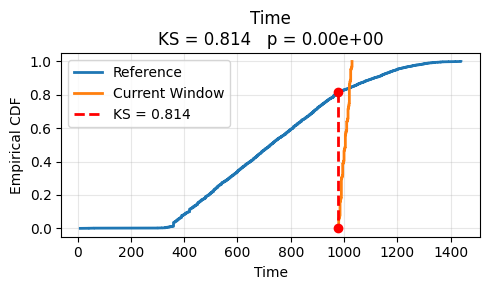

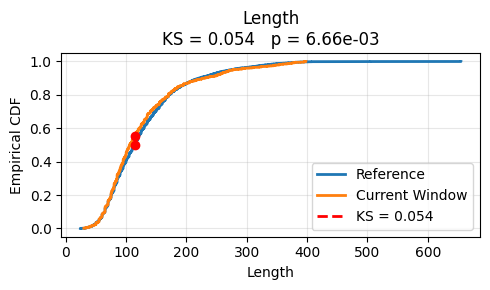

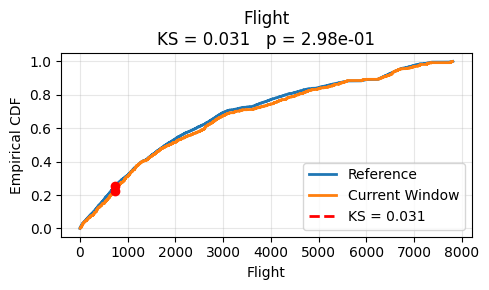

In [16]:
step_no = 1

window_size = 1000
step_size = 100

start = (step_no - 1) * step_size
end = start + window_size

current_window = df_live_stream.iloc[start:end]

for numeric_feature in numerical_features:

    print("\n\n")

    plot_ks(
        df_ref_window[numeric_feature],
        current_window[numeric_feature],
        feature_name=numeric_feature
    )

In [33]:
df = df_air.copy()
if "Delay" in df.columns:
    df["Delay"] = df["Delay"].astype(int)
else:
    print("UYARI: 'Delay' kolonu bulunamadı, mevcut kolonlar:", df.columns)

print("Veri Tipleri:")
print(df.dtypes)


numerical_features = [
    "Time",
    "Length",
    "Flight"
]

import warnings
import numpy as np
import pandas as pd
from scipy.stats import ks_2samp

warnings.filterwarnings("ignore")

df_ref_window = df.iloc[:300000].copy()

df_live_stream = df.iloc[300000:].copy().reset_index(drop=True)

print(f"Sabit Referans Pencere Boyutu : {len(df_ref_window)} satır")
print(f"Taranacak Canlı Veri Boyutu   : {len(df_live_stream)} satır")


ks_monitoring_table, bonferroni_threshold = sliding_window_ks(
    df_ref=df_ref_window,
    df_stream=df_live_stream,
    features= numerical_features,
    window_size=50000,
    step_size=5000,
    alpha=0.05
)




print("\n" + "=" * 60)
print("KAYAN PENCERE KS İZLEME TABLOSU")
print("=" * 60)

print(
    f"Bonferroni Eşiği (alpha/m): "
    f"{bonferroni_threshold:.6e}"
)

print(
    f"Toplam Oluşturulan Kayıt : "
    f"{len(ks_monitoring_table)}"
)




drift_alarms = (
    ks_monitoring_table[
        ks_monitoring_table["Drift"] == "ALARM"
    ]
    .sort_values(
        ["Step", "KS"],
        ascending=[True, False]
    )
)


print("\nAlarm Durumu Dağılımı")

print(
    ks_monitoring_table["Drift"]
    .value_counts()
)




print("\nFeature Bazında Alarm Sayısı")

print(
    ks_monitoring_table
    .groupby("Feature")["Drift"]
    .apply(
        lambda x: (x == "ALARM").sum()
    )
    .sort_values(ascending=False)
)


print("\nFeature Bazında NORMAL Sayısı")

print(
    ks_monitoring_table
    .groupby("Feature")["Drift"]
    .apply(
        lambda x: (x == "NORMAL").sum()
    )
    .sort_values(ascending=False)
)

Veri Tipleri:
Airline         object
Flight         float64
AirportFrom     object
AirportTo       object
DayOfWeek       object
Time           float64
Length         float64
Delay            int64
dtype: object
Sabit Referans Pencere Boyutu : 300000 satır
Taranacak Canlı Veri Boyutu   : 239383 satır

KAYAN PENCERE KS İZLEME TABLOSU
Bonferroni Eşiği (alpha/m): 1.666667e-02
Toplam Oluşturulan Kayıt : 114

Alarm Durumu Dağılımı
Drift
ALARM     110
NORMAL      4
Name: count, dtype: int64

Feature Bazında Alarm Sayısı
Feature
Length    38
Time      38
Flight    34
Name: Drift, dtype: int64

Feature Bazında NORMAL Sayısı
Feature
Flight    4
Length    0
Time      0
Name: Drift, dtype: int64


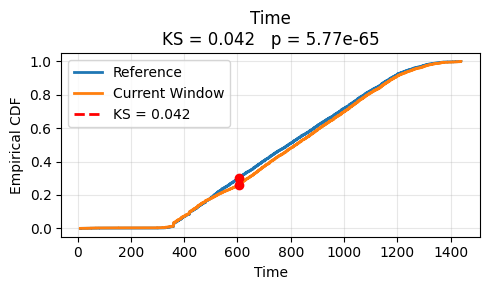

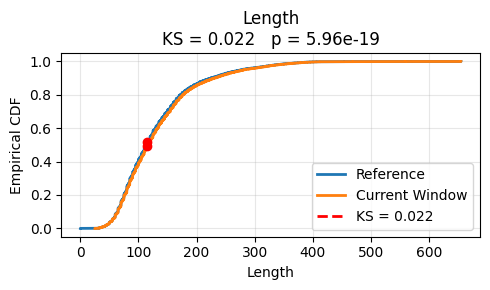

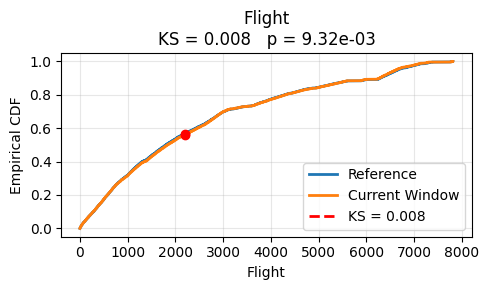

In [34]:
step_no = 1

window_size = 50000
step_size = 5000

start = (step_no - 1) * step_size
end = start + window_size

current_window = df_live_stream.iloc[start:end]

for numeric_feature in numerical_features:

    print("\n\n")

    plot_ks(
        df_ref_window[numeric_feature],
        current_window[numeric_feature],
        feature_name=numeric_feature
    )

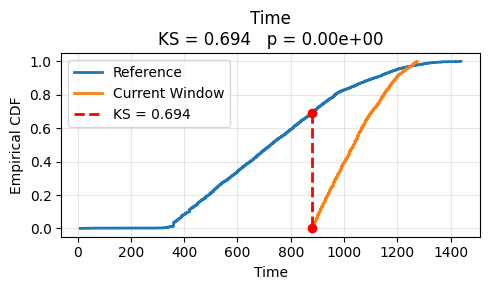

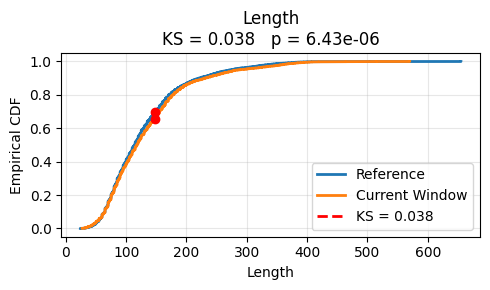

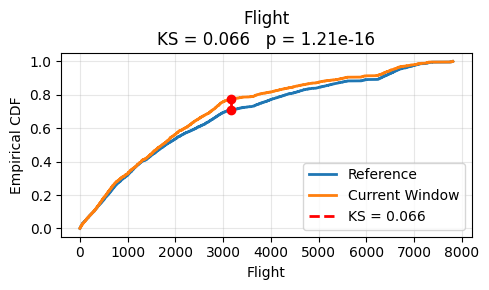

In [29]:
step_no = 1009

window_size = 5000
step_size = 500

start = (step_no - 1) * step_size
end = start + window_size

current_window = df_live_stream.iloc[start:end]

for numeric_feature in numerical_features:

    print("\n\n")

    plot_ks(
        df_ref_window[numeric_feature],
        current_window[numeric_feature],
        feature_name=numeric_feature
    )

## Wasserstein

In [35]:
df_ref_window = df.iloc[:300000].copy()

df_live_stream = (
    df.iloc[300000:]
    .copy()
    .reset_index(drop=True)
)

print(
    f"Sabit Referans Pencere Boyutu : "
    f"{len(df_ref_window)} satır"
)

print(
    f"Taranacak Canlı Veri Boyutu   : "
    f"{len(df_live_stream)} satır\n"
)


wasserstein_monitoring_table = sliding_window_wasserstein(
    df_ref=df_ref_window,
    df_stream=df_live_stream,
    features=numerical_features,
    importance_weights={},
    window_size=1000,
    step_size=100,
    threshold=0.20
)


print("=" * 60)
print("KAYAN PENCERE WASSERSTEIN İZLEME SONUÇLARI")
print("=" * 60)

print("\nDrift Durumu Dağılımı")

print(
    wasserstein_monitoring_table["Drift"]
    .value_counts()
)



Sabit Referans Pencere Boyutu : 300000 satır
Taranacak Canlı Veri Boyutu   : 239383 satır

KAYAN PENCERE WASSERSTEIN İZLEME SONUÇLARI

Drift Durumu Dağılımı
Drift
NORMAL    4580
ALARM     2572
Name: count, dtype: int64


In [36]:
print("\nFeature Bazında Alarm Sayısı")

print(
    wasserstein_monitoring_table
    .groupby("Feature")["Drift"]
    .apply(
        lambda x: (x == "ALARM").sum()
    )
    .sort_values(ascending=False)
)



Feature Bazında Alarm Sayısı
Feature
Time      2384
Length     171
Flight      17
Name: Drift, dtype: int64



Wasserstein Plot: Time


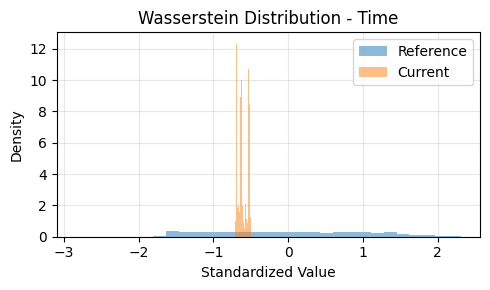

Wasserstein Distance: 0.9150
Threshold: 0.2000
Drift: ALARM

Wasserstein Plot: Length


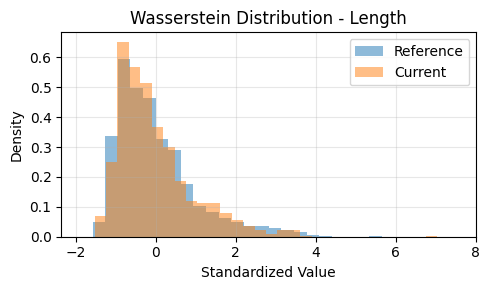

Wasserstein Distance: 0.0444
Threshold: 0.2000
Drift: NORMAL

Wasserstein Plot: Flight


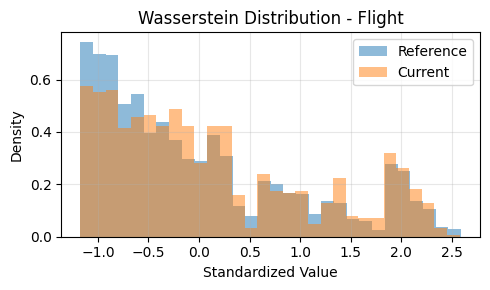

Wasserstein Distance: 0.1154
Threshold: 0.2000
Drift: NORMAL


In [37]:
step_no = 1

window_size = 1000
step_size = 100

start = (step_no - 1) * step_size
end = start + window_size

current_window = df_live_stream.iloc[start:end]


for feature in numerical_features:

    print("\n" + "=" * 60)
    print(f"Wasserstein Plot: {feature}")
    print("=" * 60)

    plot_wasserstein(
        df_ref_window[feature],
        current_window[feature],
        feature_name=feature
    )